In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import sparse
from scipy.sparse.linalg import spsolve
from scipy.signal import savgol_filter
from sklearn.decomposition import PCA

In [10]:
def als_baseline(y, D, L, p = 0.01, niter = 10):
    """
    Asymmetric Least Squares baseline correction.
    
    Parameters:
        y    : spectrum intensity array
        lam  : smoothness (1e3 – 1e7); higher = smoother baseline
        p    : asymmetry (0.001 – 0.1); lower = baseline hugs the bottom
        niter: number of iterations
    """
    w = np.ones(L)

    for _ in range(niter):
        W = sparse.diags(w)
        Z = W + D
        z = spsolve(Z, w*y)
        w = p * (y > z) + (1 - p) * (y <= z)
    return z

In [15]:
df = pd.read_csv("02_feature_matrix_raw_T.csv", header = 0)

dataFrame = df.drop(columns=["Sample_ID", "Replica", "Origin", "Type"])

ranges = [(24, 37), (50, 67), (70, 87), (88, 95), (96, 112), (125, 135), (137, 159)]
indices = np.concatenate([np.arange(s, e) for s, e in ranges])
spectrums = dataFrame.iloc[indices].reset_index(drop=True).copy()
spectrums.iloc[:5, :5].head()


,Spectrum_ID,Subtype,4000.0,3999.0,3998.0
0,25,Cotton,99.10,99.11,99.12
1,26,Cotton,99.26,99.28,99.30
2,27,Cotton,99.89,99.89,99.89
3,28,Cotton,99.59,99.60,99.61
4,29,Cotton,100.71,100.72,100.74


In [12]:
L = spectrums.iloc[:, 2:].shape[1]
D = sparse.diags([1, -2, 1], [0, 1, 2], shape=(L - 2, L))
D = 1e5 * D.T @ D 

corrected = spectrums.copy()

for i in range(spectrums.shape[0]):
    y = spectrums.iloc[i, 2:].values.astype(float)
    baseline = als_baseline(y, D, L)
    corrected.iloc[i, 2:] = y - baseline

meta = corrected.iloc[:, :2].reset_index(drop=True)
values = corrected.iloc[:, 2:].astype(float)
    
normalized = values.copy()

for i in range(values.shape[0]):
    row = values.iloc[i].values
    normalized.iloc[i, :] = (row - row.mean())/row.std()

smoothed = normalized.copy()

for i in range(normalized.shape[0]):
    smoothed.iloc[i, :] = savgol_filter(normalized.iloc[i, :], window_length=9, polyorder=3)

final_df = pd.concat([meta, smoothed], axis=1)

final_df.iloc[:20, :6].head()

,Spectrum_ID,Subtype,4000.0,3999.0,3998.0,3997.0
0,25,Cotton,-0.622644,-0.612657,-0.610001,-0.613199
1,26,Cotton,-0.615384,-0.601185,-0.590786,-0.584005
2,27,Cotton,-0.581537,-0.581484,-0.581587,-0.581481
3,28,Cotton,-0.639472,-0.626938,-0.620960,-0.619838
4,29,Cotton,-0.629731,-0.620984,-0.612284,-0.604668


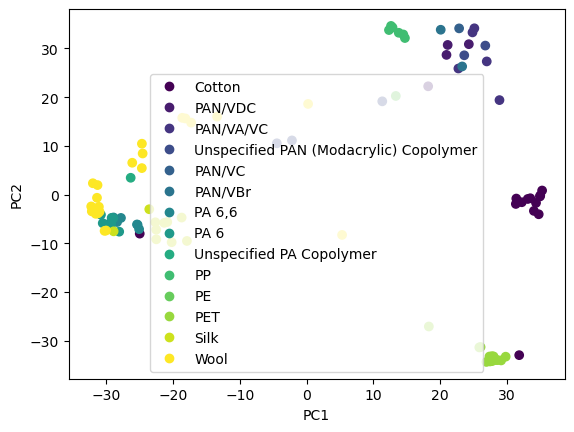

In [ ]:
from matplotlib.pyplot import scatter


pca_data = final_df.copy()
labels = final_df["Subtype"]
codes, uniques = pd.factorize(labels)

pca = PCA(n_components=2)
pca_data = pca.fit_transform(final_df.iloc[:, 2:].values)

scatter_plot = plt.scatter(pca_data[:, 0], pca_data[:, 1], c=pd.factorize(labels)[0])
plt.legend(handles = scatter_plot.legend_elements()[0], labels=list(uniques))

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

## Wallahi we visualize

### Which IDs get visualized

In [93]:
selected_visual_ids = [0,1,3] # For the 4 different graphs
selected_comparison_ids = [0] # For comparison graphs

### Baseline Visualization

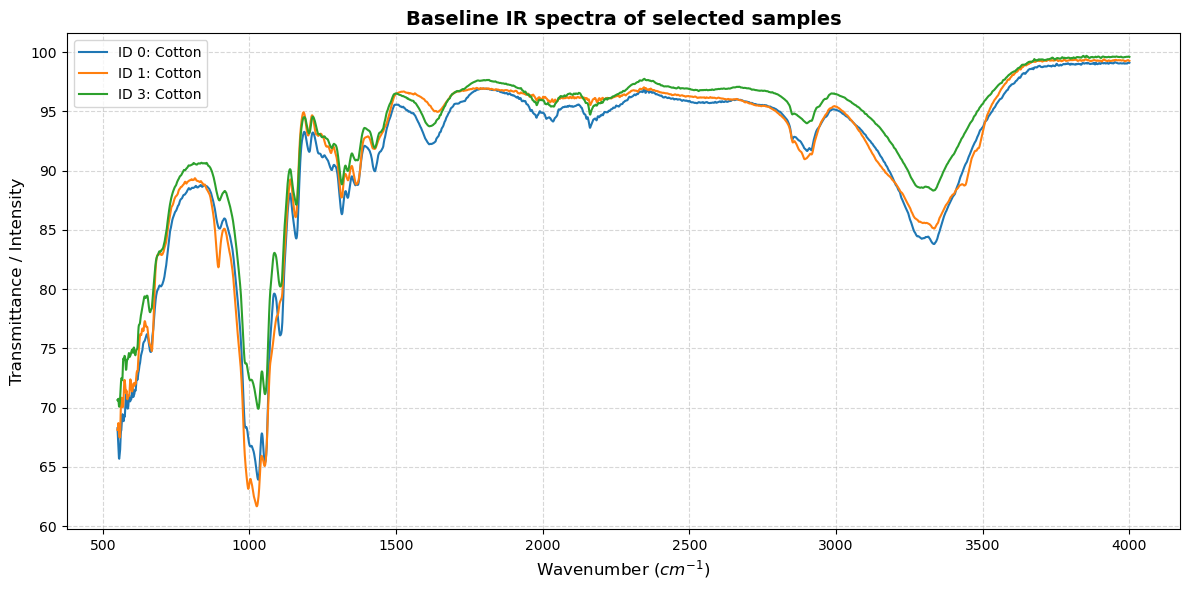

In [94]:
# ------------------ Baseline Visualization ------------------

baseline_wavenumber_cols = spectrums.columns.drop(["Spectrum_ID", "Subtype"])
baseline_wavenumbers = baseline_wavenumber_cols.astype(float)

baseline_selected_spectra = spectrums.loc[selected_visual_ids, baseline_wavenumber_cols]

plt.figure(figsize=(12, 6))
plt.plot(baseline_wavenumbers, baseline_selected_spectra.T)
plt.title("Baseline IR spectra of selected samples", fontsize=14, fontweight='bold')
plt.xlabel("Wavenumber ($cm^{-1}$)", fontsize=12)
plt.ylabel("Transmittance / Intensity", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
legend_labels = [f"ID {sid}: {spectrums.loc[sid, 'Subtype']}" for sid in selected_visual_ids]
plt.legend(legend_labels, loc="best")
plt.tight_layout()


### Corrected Visualization

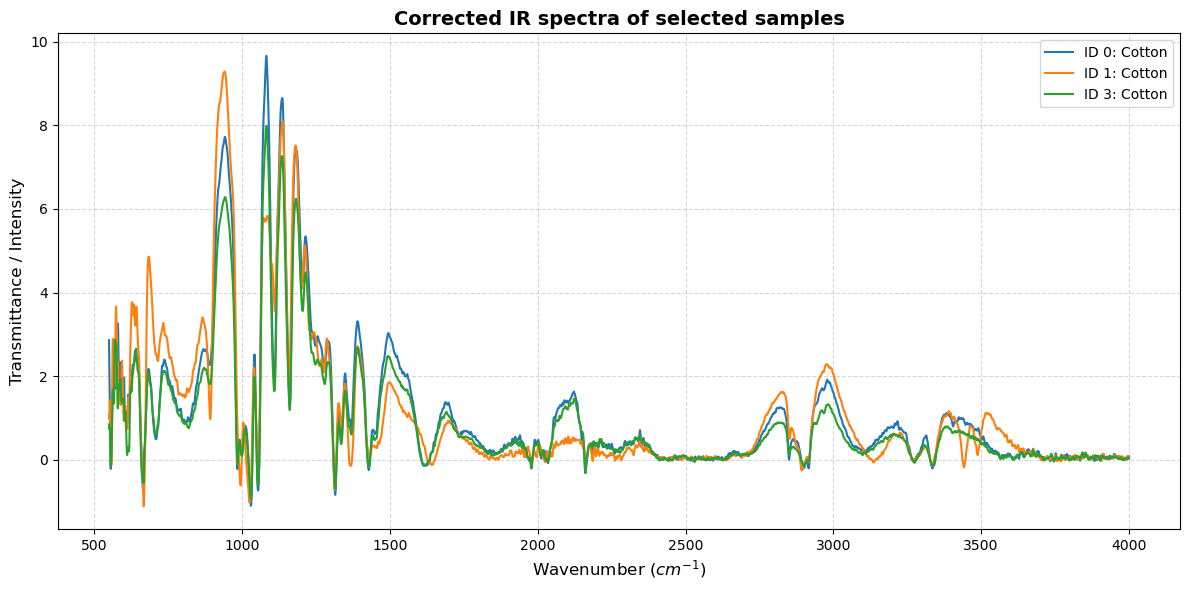

In [95]:
corrected_wavenumber_cols = values.columns
corrected_wavenumbers = corrected_wavenumber_cols.astype(float)

corrected_selected_spectra = values.loc[selected_visual_ids, baseline_wavenumber_cols]

plt.figure(figsize=(12, 6))
plt.plot(corrected_wavenumbers, corrected_selected_spectra.T)
plt.title("Corrected IR spectra of selected samples", fontsize=14, fontweight='bold')
plt.xlabel("Wavenumber ($cm^{-1}$)", fontsize=12)
plt.ylabel("Transmittance / Intensity", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
legend_labels = [f"ID {sid}: {spectrums.loc[sid, 'Subtype']}" for sid in selected_visual_ids]
plt.legend(legend_labels, loc="best")
plt.tight_layout()

### Normalized Visualization

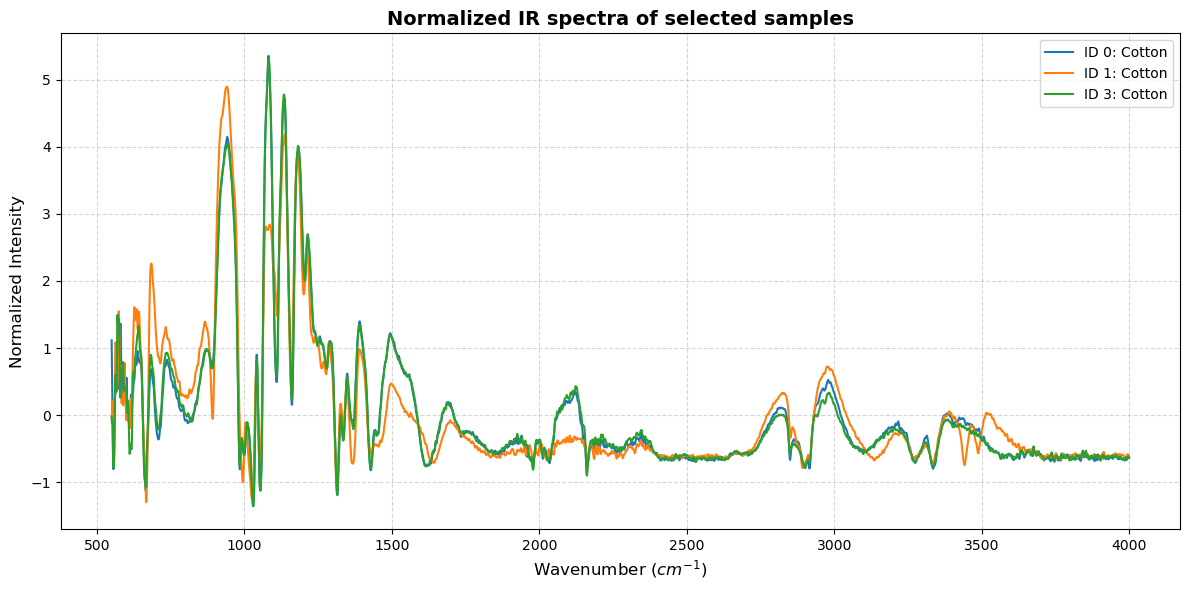

In [96]:
normalized_wavenumber_cols = normalized.columns
normalized_wavenumbers = normalized_wavenumber_cols.astype(float)

normalized_selected_spectra = normalized.loc[selected_visual_ids, baseline_wavenumber_cols]

plt.figure(figsize=(12, 6))
plt.plot(normalized_wavenumbers, normalized_selected_spectra.T)
plt.title("Normalized IR spectra of selected samples", fontsize=14, fontweight='bold')
plt.xlabel("Wavenumber ($cm^{-1}$)", fontsize=12)
plt.ylabel("Normalized Intensity", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
legend_labels = [f"ID {sid}: {spectrums.loc[sid, 'Subtype']}" for sid in selected_visual_ids]
plt.legend(legend_labels, loc="best")
plt.tight_layout()

### Smoothed Visualization

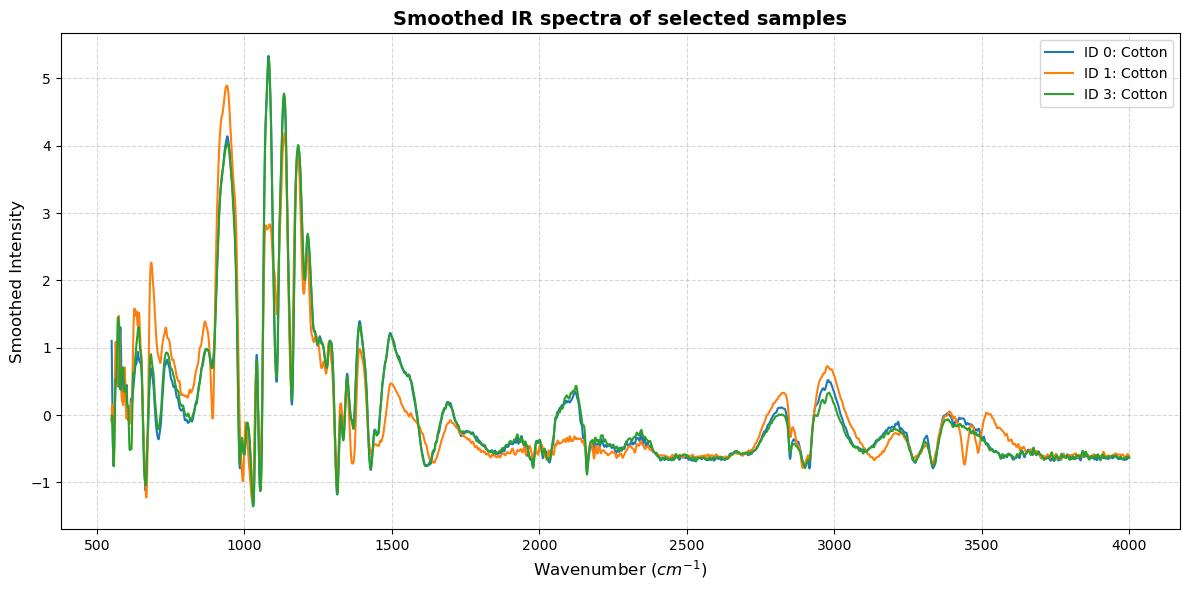

In [ ]:
smoothed_wavenumber_cols = smoothed.columns
smoothed_wavenumbers = smoothed_wavenumber_cols.astype(float)

smoothed_selected_spectra = smoothed.loc[selected_visual_ids, baseline_wavenumber_cols]

plt.figure(figsize=(12, 6))
plt.plot(smoothed_wavenumbers, smoothed_selected_spectra.T)
plt.title("Smoothed IR spectra of selected samples", fontsize=14, fontweight='bold')
plt.xlabel("Wavenumber ($cm^{-1}$)", fontsize=12)
plt.ylabel("Smoothed Intensity", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
legend_labels = [f"ID {sid}: {spectrums.loc[sid, 'Subtype']}" for sid in selected_visual_ids]
plt.legend(legend_labels, loc="best")
plt.tight_layout()

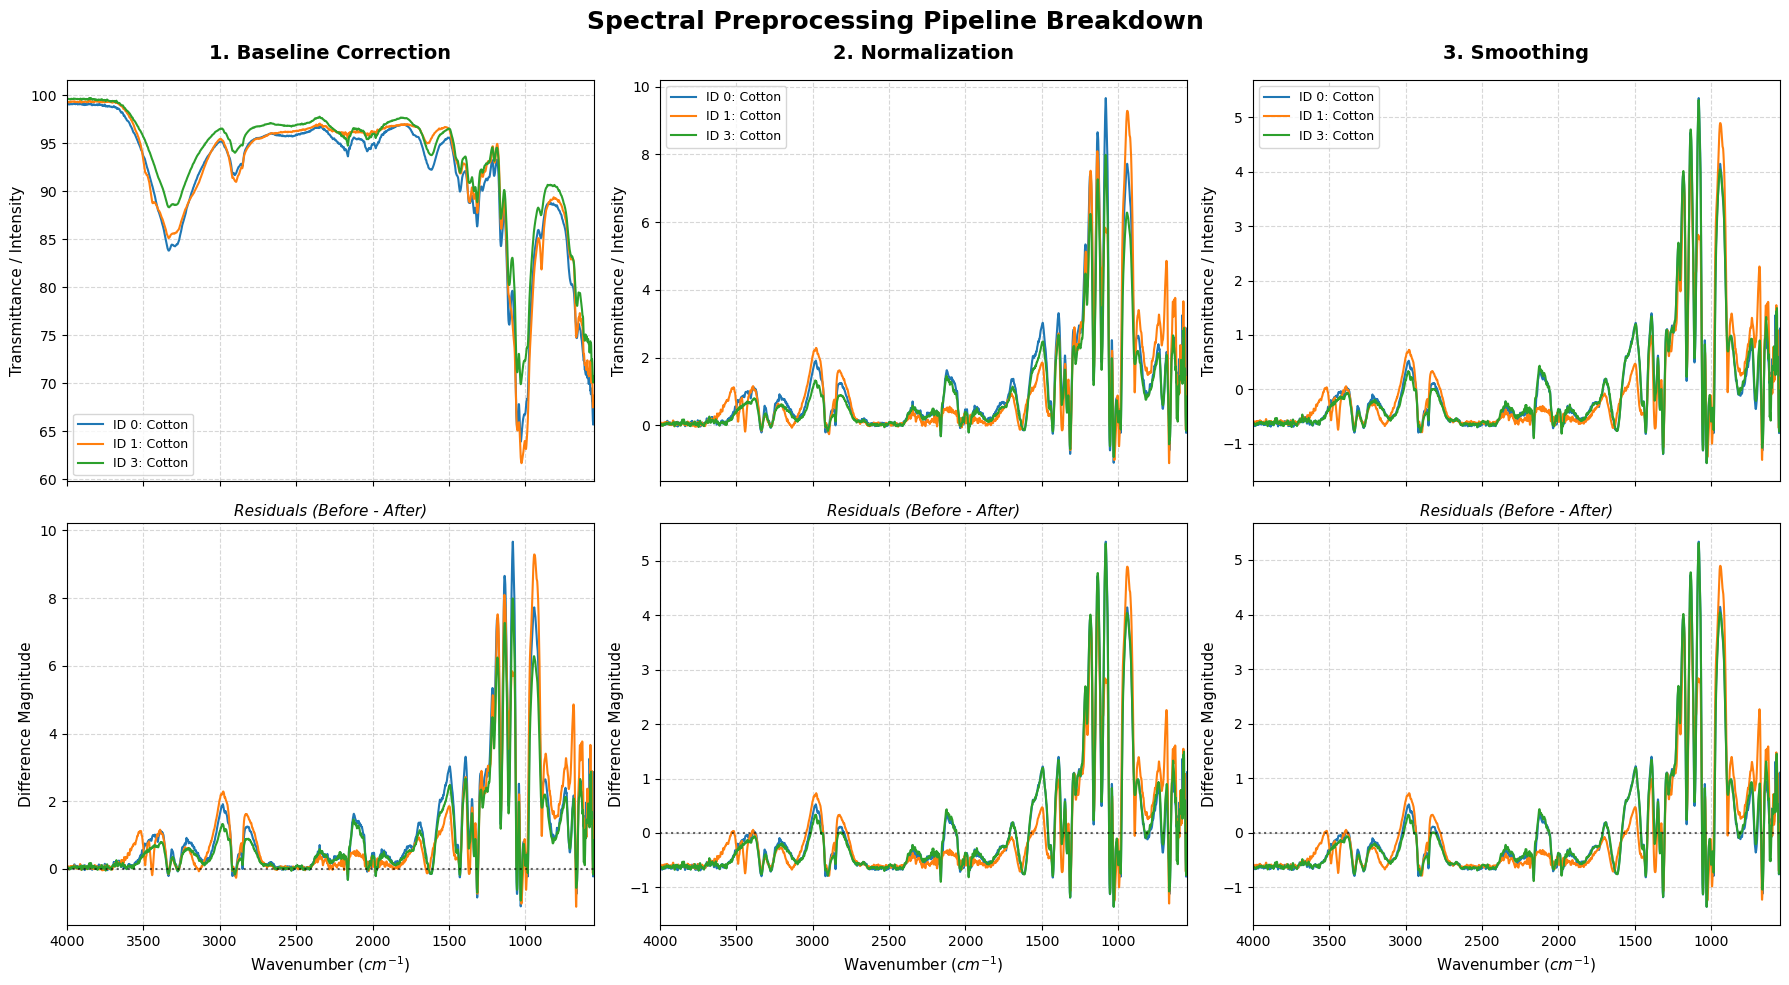

In [106]:
processing_steps = [
    (baseline_selected_spectra, corrected_selected_spectra, "1. Baseline Correction"),
    (corrected_selected_spectra, normalized_selected_spectra, "2. Normalization"),
    (normalized_selected_spectra, smoothed_selected_spectra, "3. Smoothing")
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True)

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

for col_idx, (before_df, after_df, step_title) in enumerate(processing_steps):

    ax_top = axes[0, col_idx]
    ax_bottom = axes[1, col_idx]

    for idx, sid in enumerate(selected_visual_ids):

        color = colors[idx % len(colors)]

        ax_top.plot(baseline_wavenumbers, before_df.loc[sid], label=f"ID {sid}: {spectrums.loc[sid, 'Subtype']}", color=color)
        ax_bottom.plot(baseline_wavenumbers, after_df.loc[sid], label=f"ID {sid}: {spectrums.loc[sid, 'Subtype']}", color=color)

    ax_top.set_title(step_title, fontsize=14, fontweight='bold', pad=15)
    ax_top.set_ylabel("Transmittance / Intensity", fontsize=11)
    ax_top.grid(True, linestyle="--", alpha=0.5)
    ax_top.legend(loc="best", fontsize=9)

    ax_bottom.set_title("Residuals (Before - After)", fontsize=11, style='italic')
    ax_bottom.set_xlabel("Wavenumber ($cm^{-1}$)", fontsize=11)
    ax_bottom.set_ylabel("Difference Magnitude", fontsize=11)
    ax_bottom.grid(True, linestyle="--", alpha=0.5)
    ax_bottom.axhline(0, color='black', linestyle=':', alpha=0.6)

plt.xlim(baseline_wavenumbers.max(), baseline_wavenumbers.min())
fig.suptitle("Spectral Preprocessing Pipeline Breakdown", fontsize=18, fontweight='bold', y=0.98)

plt.tight_layout()